In [1]:
import numpy as np
import xarray as xr
import scipy.optimize as optimize
import matplotlib.pyplot as plt
import pandas as pd
import weatherdata as wd

## Retrieving

In [2]:
# import retrieve_modelled_data as ret
# filesList = ret.get_list()
# data = ret.main(filesList, 2, output_dir='/nird/projects/NS9873K/emile/unseen-storm-forecasts/2_days_event/data')

In [2]:
data = xr.open_dataarray(
    'data/retrieved-full-2.nc'
)

In [4]:
# import preprocess as ppro
# processed = ppro.maximize(data)
# processed.to_netcdf('data/processed.nc')
# maxs = processed.max(dim="time")
# maxs.to_netcdf('data/maxs.nc')

In [3]:
processed = xr.open_dataarray('data/processed.nc')
maxs = xr.open_dataarray('data/maxs.nc')

In [6]:
# import retrieve_rea_data as ret_rea
# rea_data = wd.sum_over_time(
#     ret_rea.main(ret_rea.fileList),
#     span=2,
#     edges=False
# )
# rea_data.to_netcdf('data/retrieved-rea-2.nc')

In [4]:
rea_data = xr.open_dataarray('data/retrieved-rea-2.nc')

In [8]:
# import rea_maxs
# era5 = rea_maxs.main(rea_data)
# era5.to_netcdf('data/processed-rea-2.nc')

In [5]:
era5 = xr.open_dataarray('data/processed-rea-2.nc')

## Tests

In [6]:
import test_fidelity as fid
import test_stability as stab
import test_independence as ind

In [11]:
# maxs_aug = maxs.sel(date=maxs.month==8)
# maxs_aug.to_netcdf('august/maxs-aug.nc')
# processed_aug = processed.sel(date=processed.month==8)
# processed_aug.to_netcdf('august/processed-aug.nc')

In [7]:
processed_aug = xr.open_dataarray('august/processed-aug.nc')
maxs_aug = xr.open_dataarray('august/maxs-aug.nc')

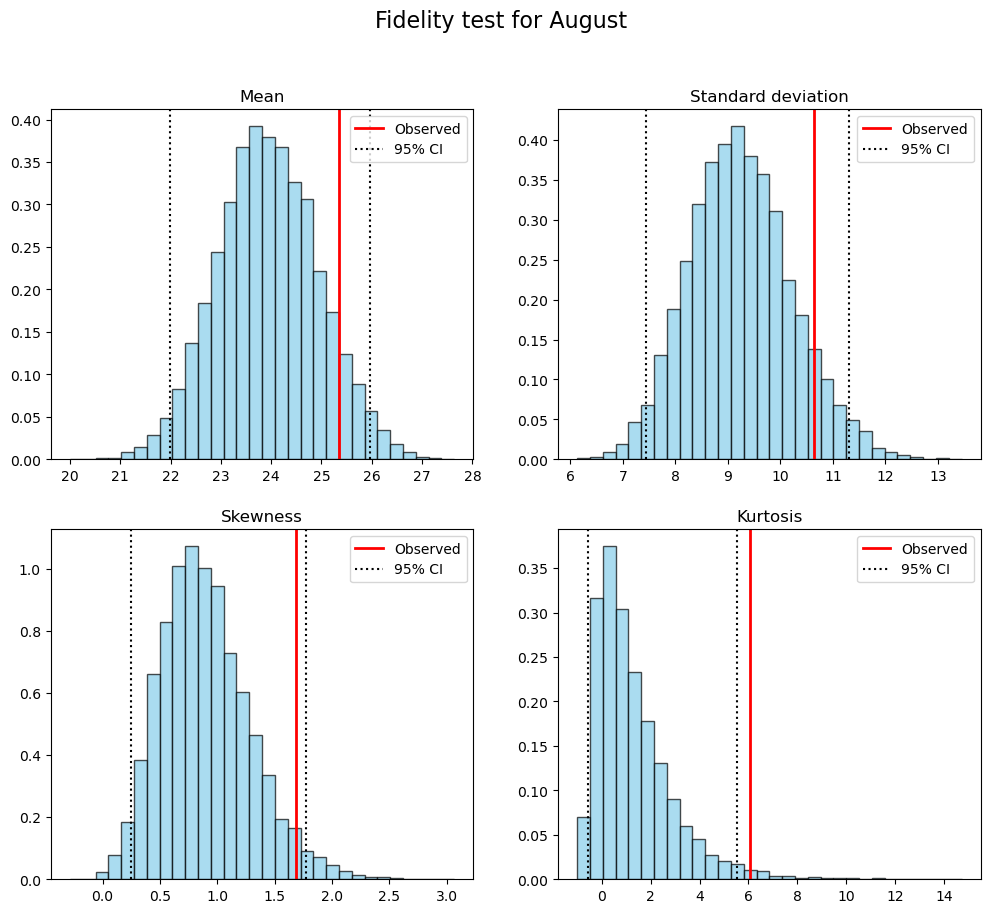

In [13]:
rea, mod = fid.main("august/maxs-aug.nc", "data/processed-rea-2.nc")
fid.plot(rea, mod, "august/raw", "August", show=True)

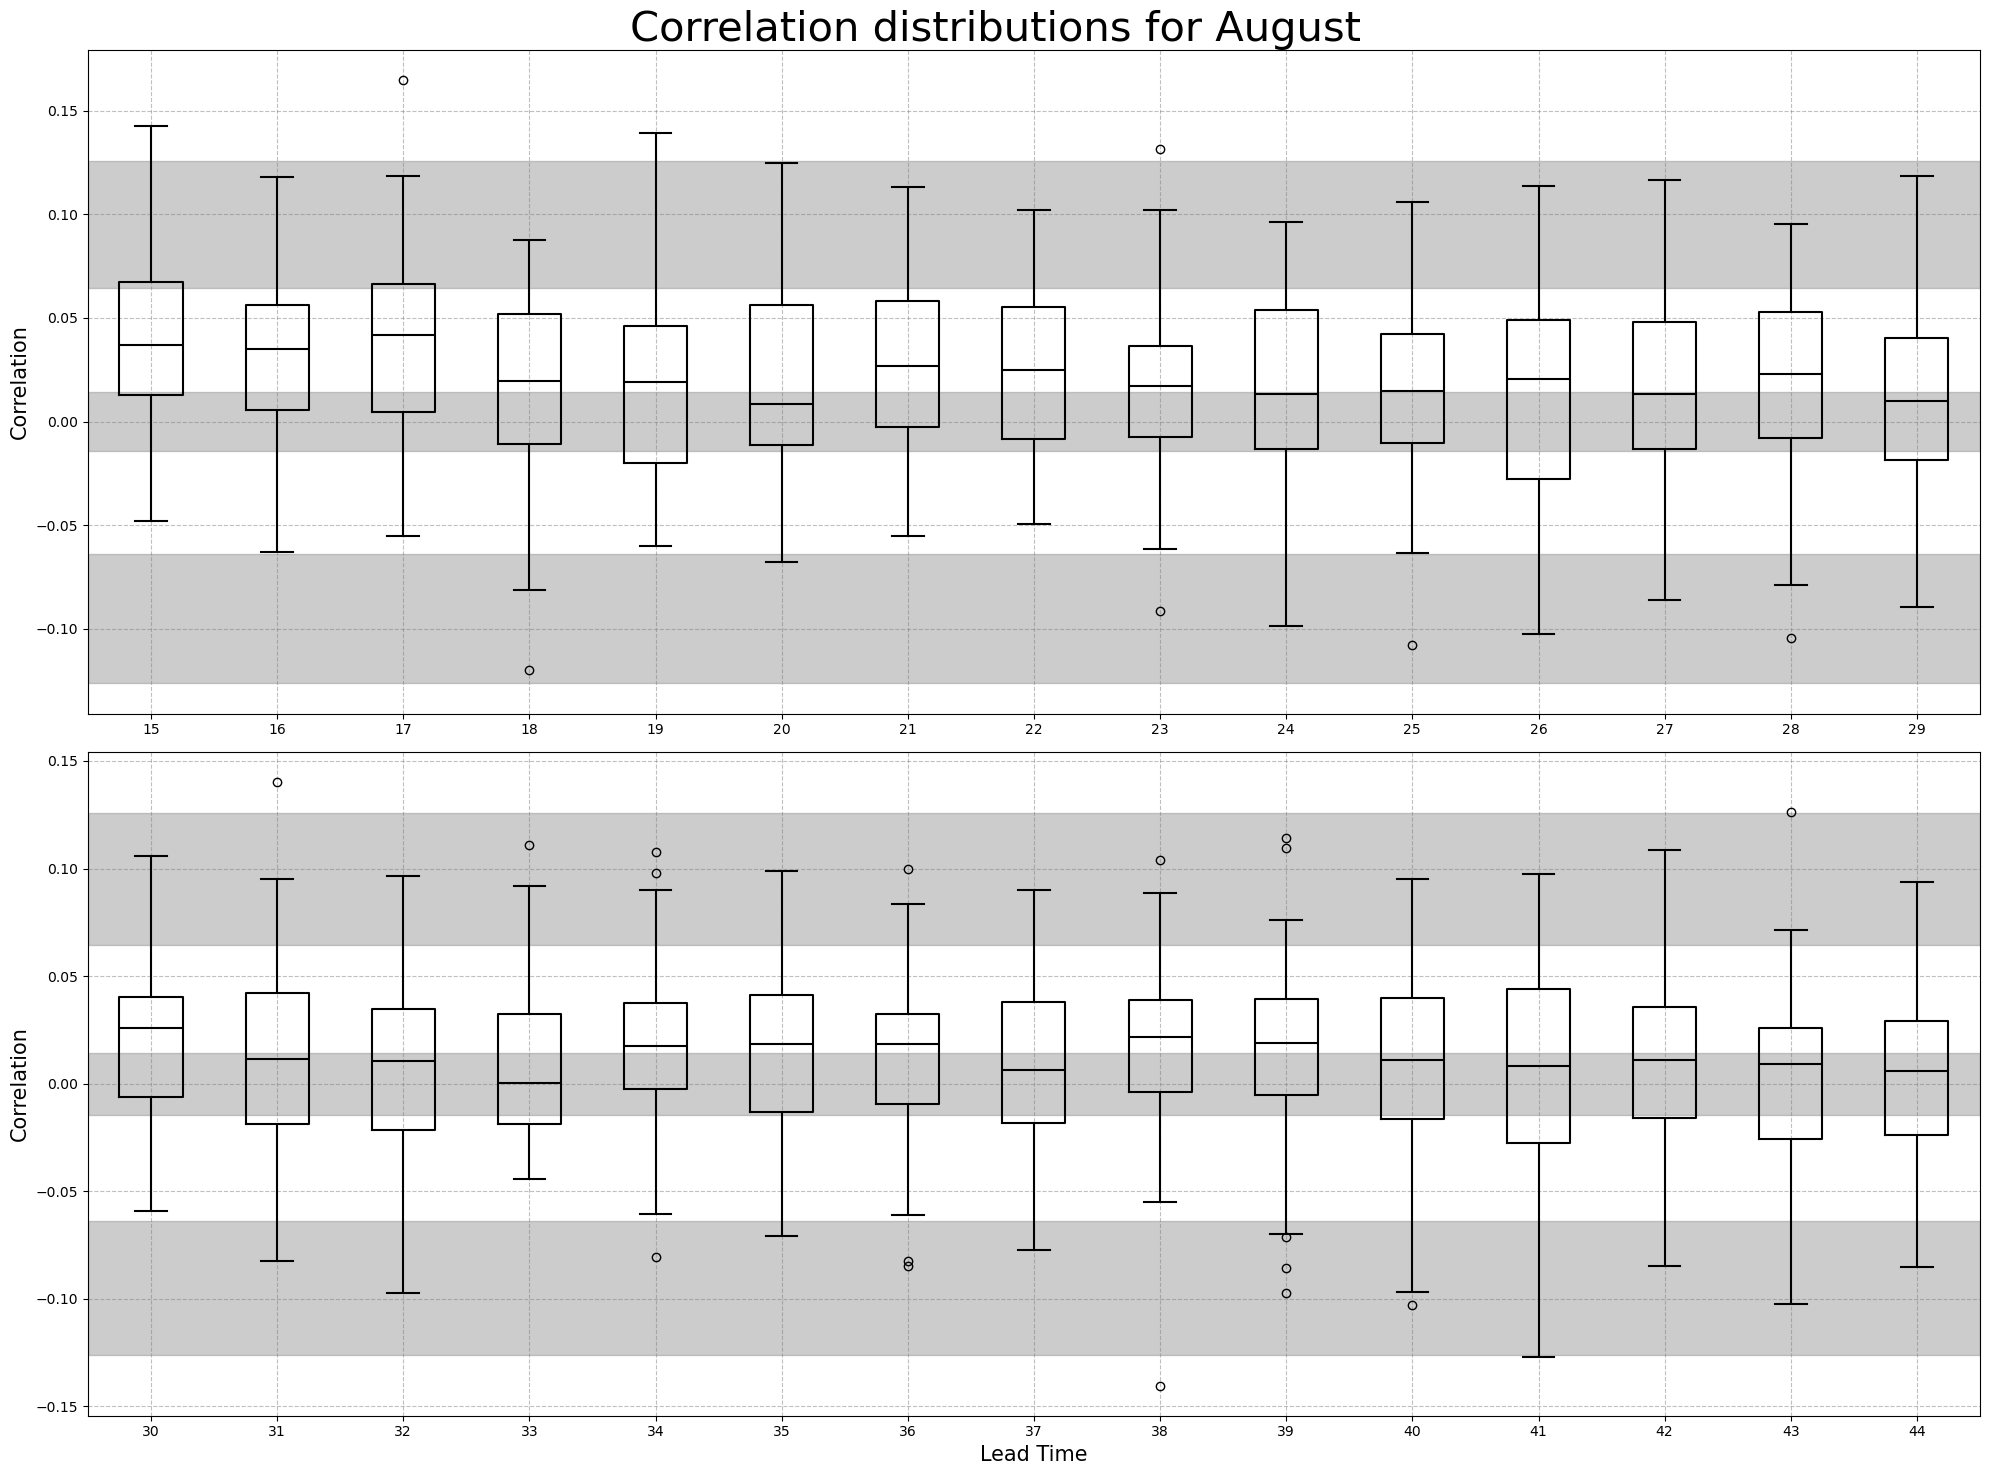

In [14]:
correl, interv = ind.correlation(processed_aug)
ind.plot_correlations(correl, interv, "august/raw", show=True)

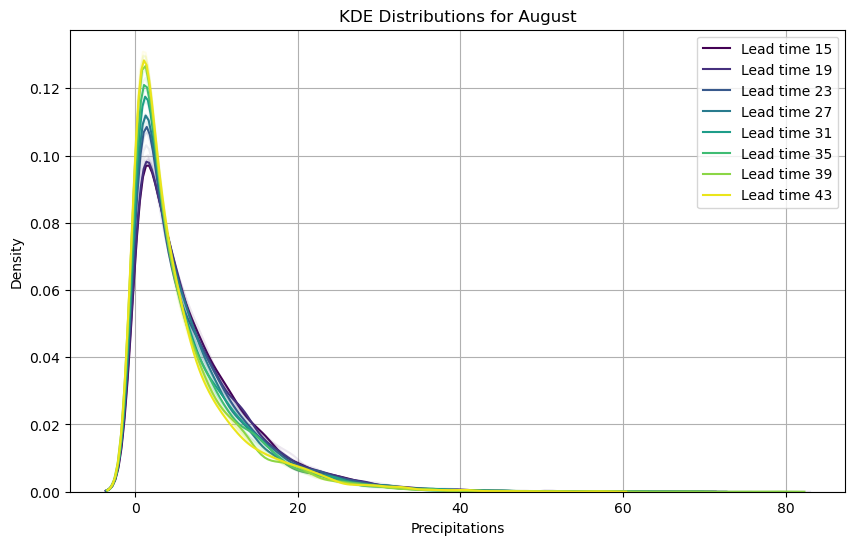

In [15]:
stab.plot_kde_distributions(processed_aug, "august/raw", show=True)

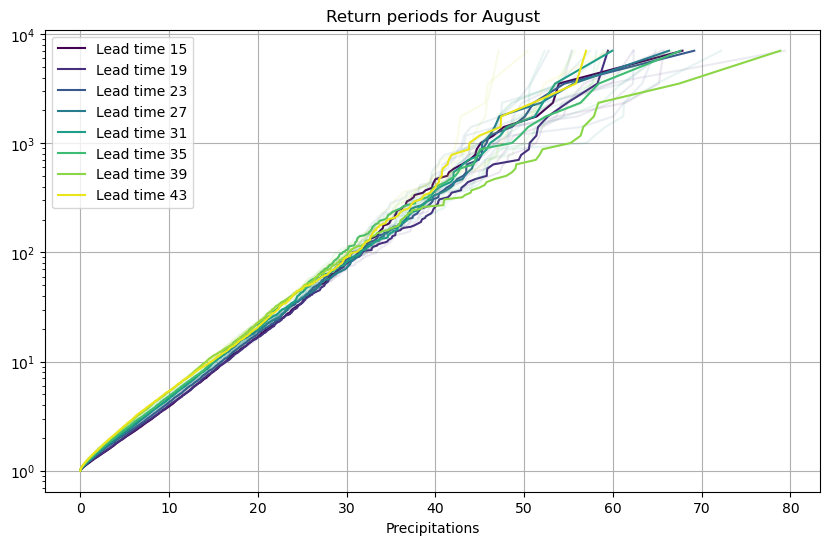

In [16]:
stab.plot_return_period(processed_aug, "august/raw", show=True)

### Correct stability

In [8]:
stacked = processed_aug.copy().stack(
    d=["date", "number"]
).reset_index('d').drop_vars(
    ["date", "number", "month"]
)
vals = stacked.values
vals = vals[:, ~np.isnan(vals[0])]
vals_sorted = np.sort(vals, axis=1)
refs = np.sort(vals[0], axis=-1)
vals_diffs = (vals_sorted - refs)
diffs = xr.DataArray(
    data=np.array([vals_sorted, vals_diffs]),
    dims=("var",) + stacked.dims,
    coords=dict(
        var=["val", "diff"],
        time=stacked.time
    )
)
diffs.to_netcdf('diffs.nc')

In [12]:
def polyfunc(x, a, b, c):
    return a * x**2 + b * x + c
def expfunc(x, a, b, c):
    return a * np.exp(-b * x) + c

In [1]:
corrected_1 = processed_aug.copy()
for tid, t in enumerate(corrected_1.time.values):
    y = diffs.sel(var="diff", time=t).values
    x = diffs.sel(var="val", time=t).values

    [p_opt, p_cov] = optimize.curve_fit(expfunc, x, y)
    (a, b, c) = tuple(p_opt)

    vals = corrected_1.sel(time=t).values
    corrected_1[...,tid] -= expfunc(vals, a, b, c)

corrected_1.to_netcdf("august/corrected_1.nc")
maxs_corrected_1 = corrected_1.max(dim="time")
maxs_corrected_1.to_netcdf("august/maxs_corrected_1.nc")

NameError: name 'processed_aug' is not defined

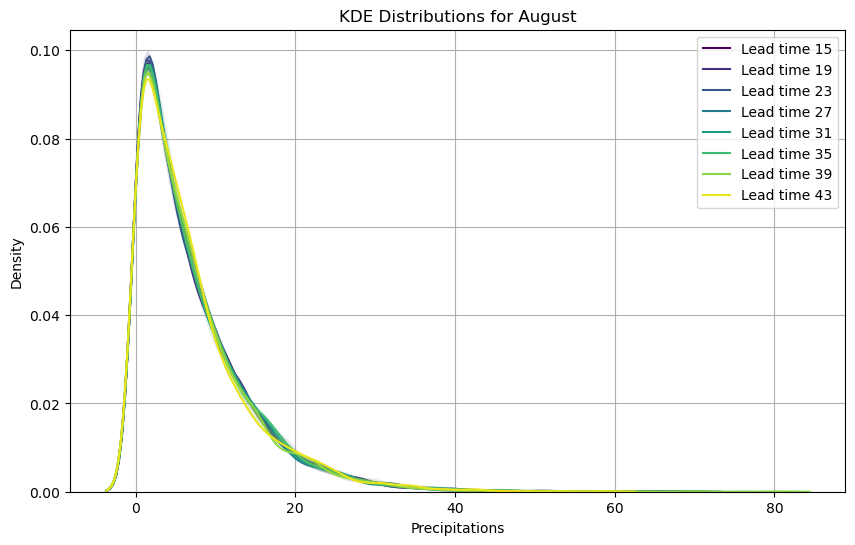

In [24]:
stab.plot_kde_distributions(corrected_1, "august", show=True)

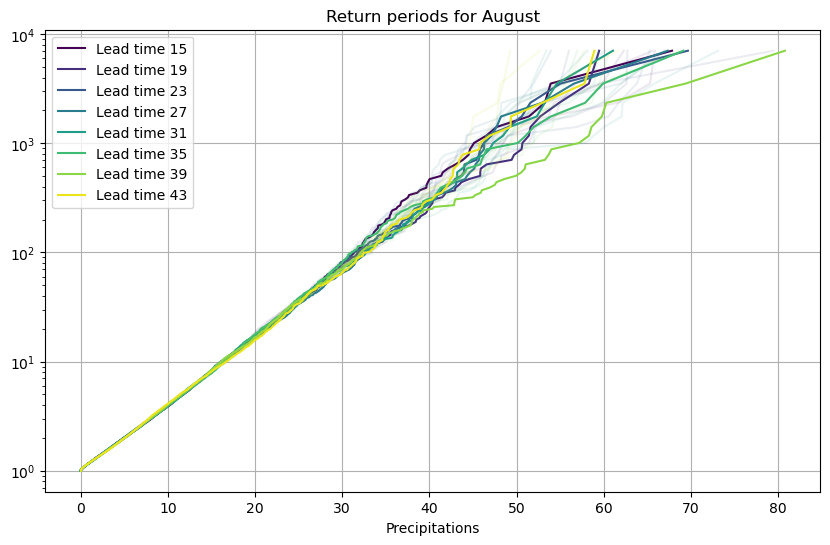

In [25]:
stab.plot_return_period(corrected_1, "august", show=True)

In [26]:
corrected_2 = processed_aug.copy()
for tid, t in enumerate(corrected_2.time.values):
    y = diffs.sel(var="diff", time=t).values
    x = diffs.sel(var="val", time=t).values

    [p_opt, p_cov] = optimize.curve_fit(polyfunc, x, y)
    (a, b, c) = tuple(p_opt)

    vals = corrected_2.sel(time=t).values
    corrected_2[...,tid] -= polyfunc(vals, a, b, c)

In [27]:
corrected_2.to_netcdf("august/corrected_2.nc")
maxs_corrected_2 = corrected_2.max(dim="time")
maxs_corrected_2.to_netcdf("august/maxs_corrected_2.nc")

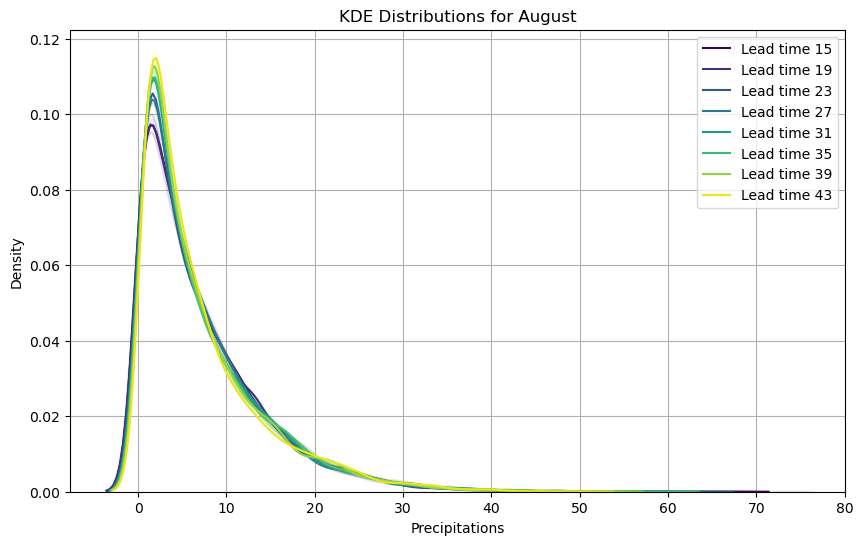

In [28]:
stab.plot_kde_distributions(corrected_2, "august", show=True)

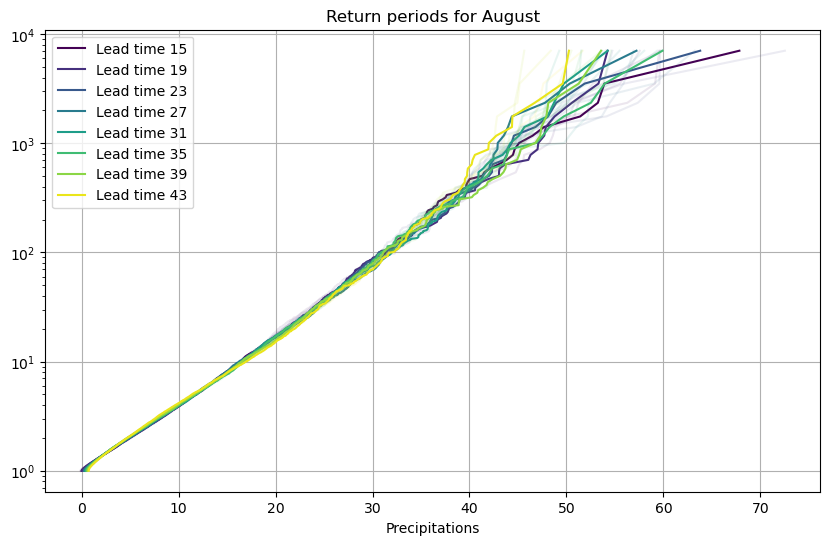

In [29]:
stab.plot_return_period(corrected_2, "august", show=True)

### Correct independance

In [30]:
corr, interv = ind.correlation(corrected_1)

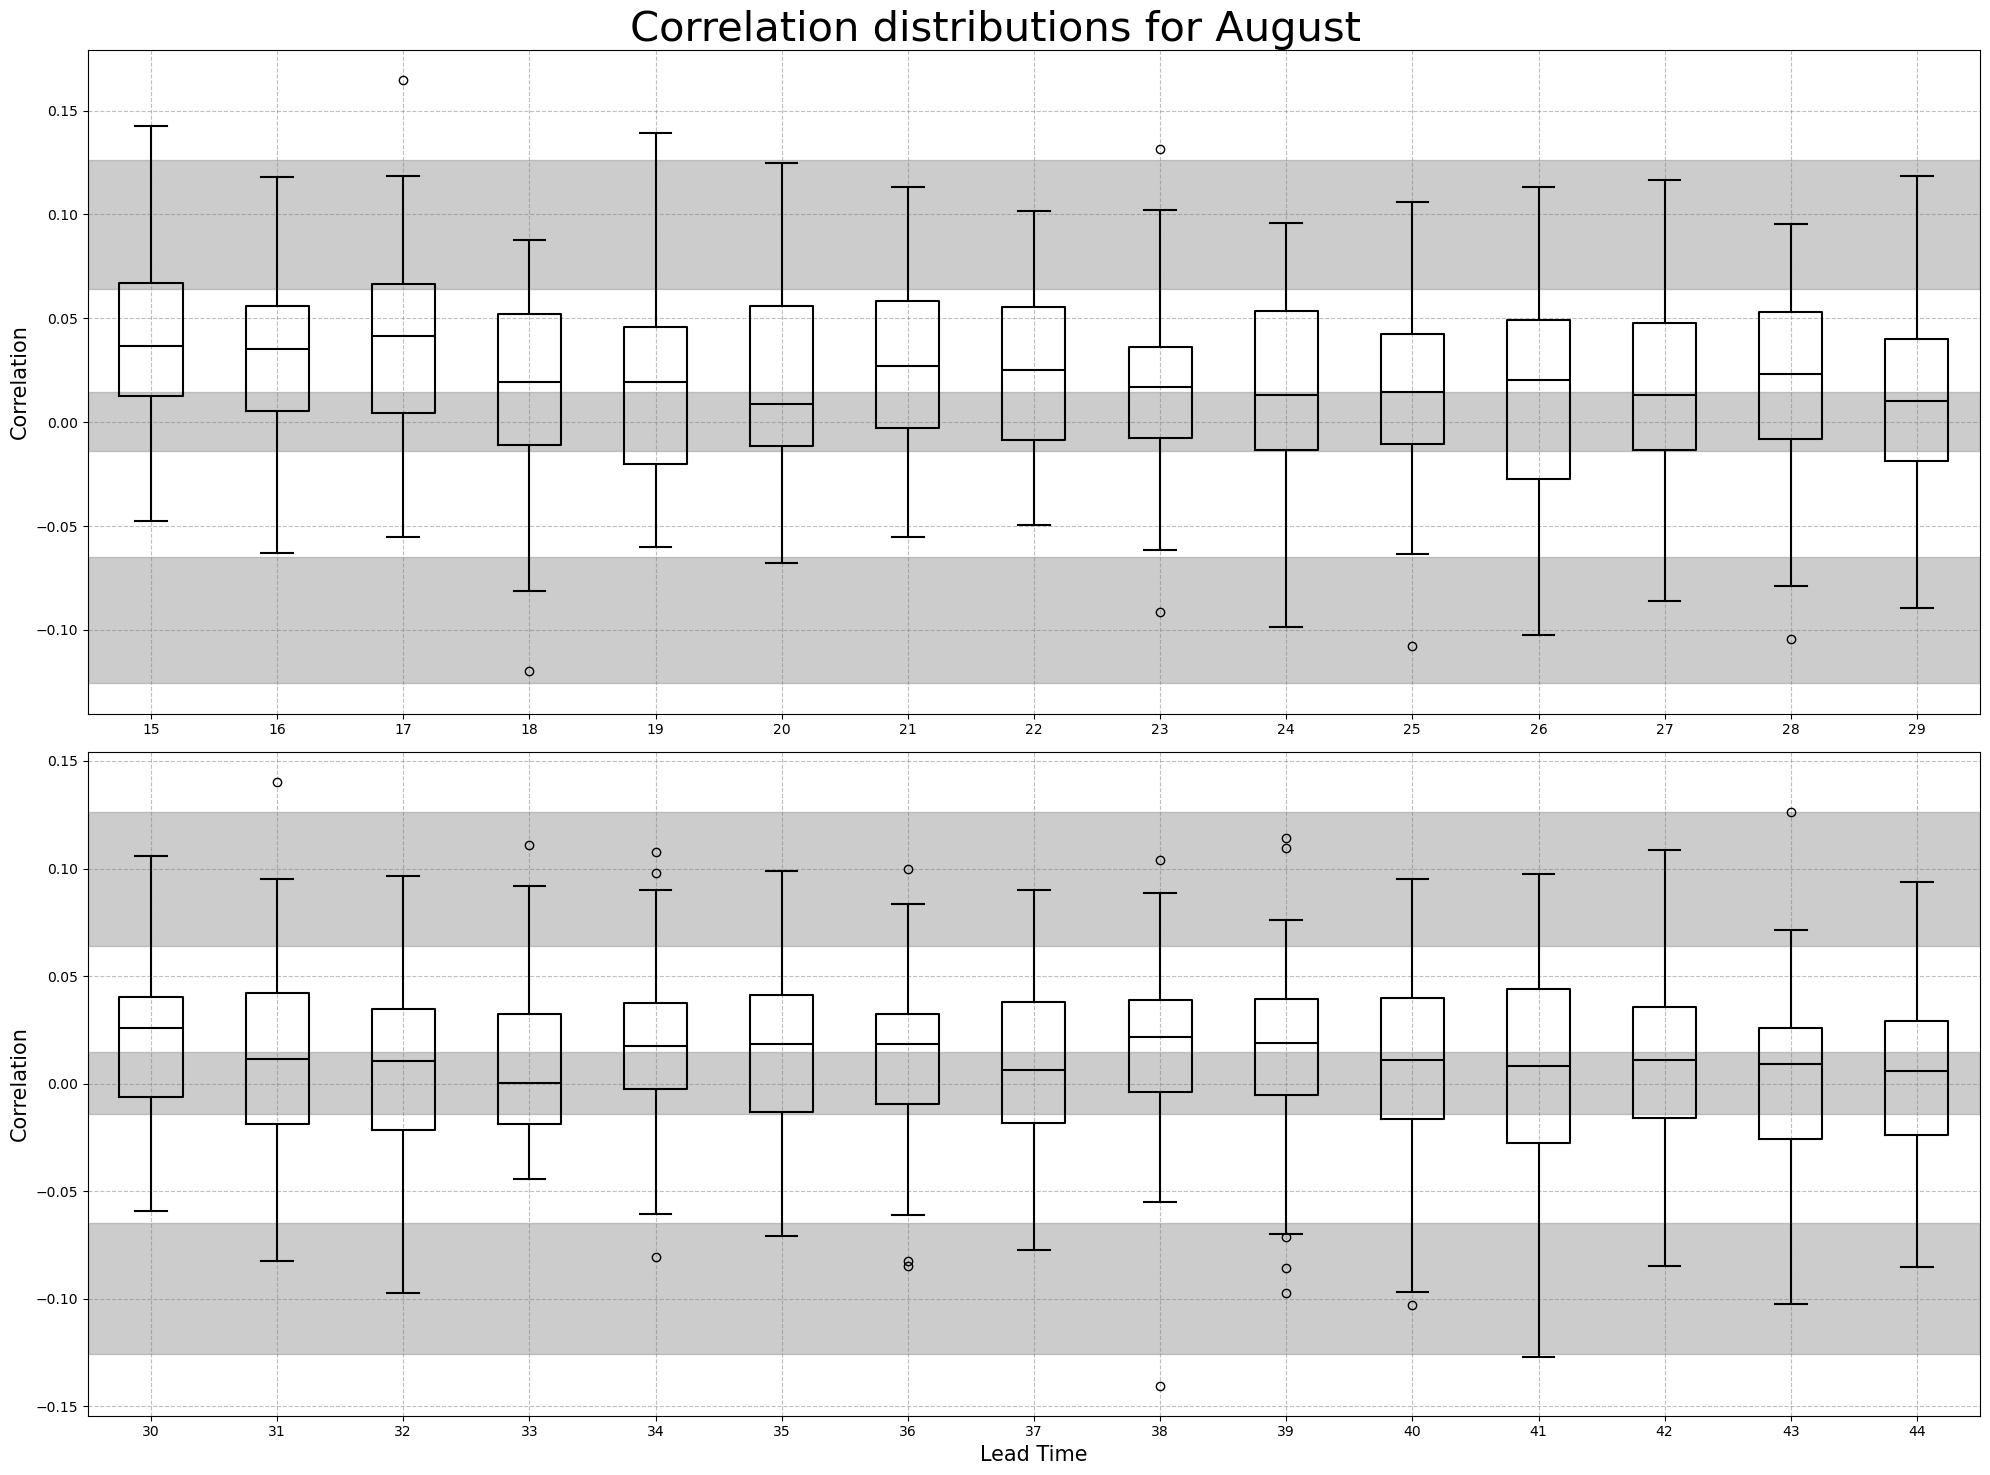

In [31]:
ind.plot_correlations(corr, interv, "august", show=True)

### Correct fidelity

In [15]:
rea, mod = fid.main(
    "august/maxs_corrected_1.nc",
    "data/processed-rea-2.nc"
)

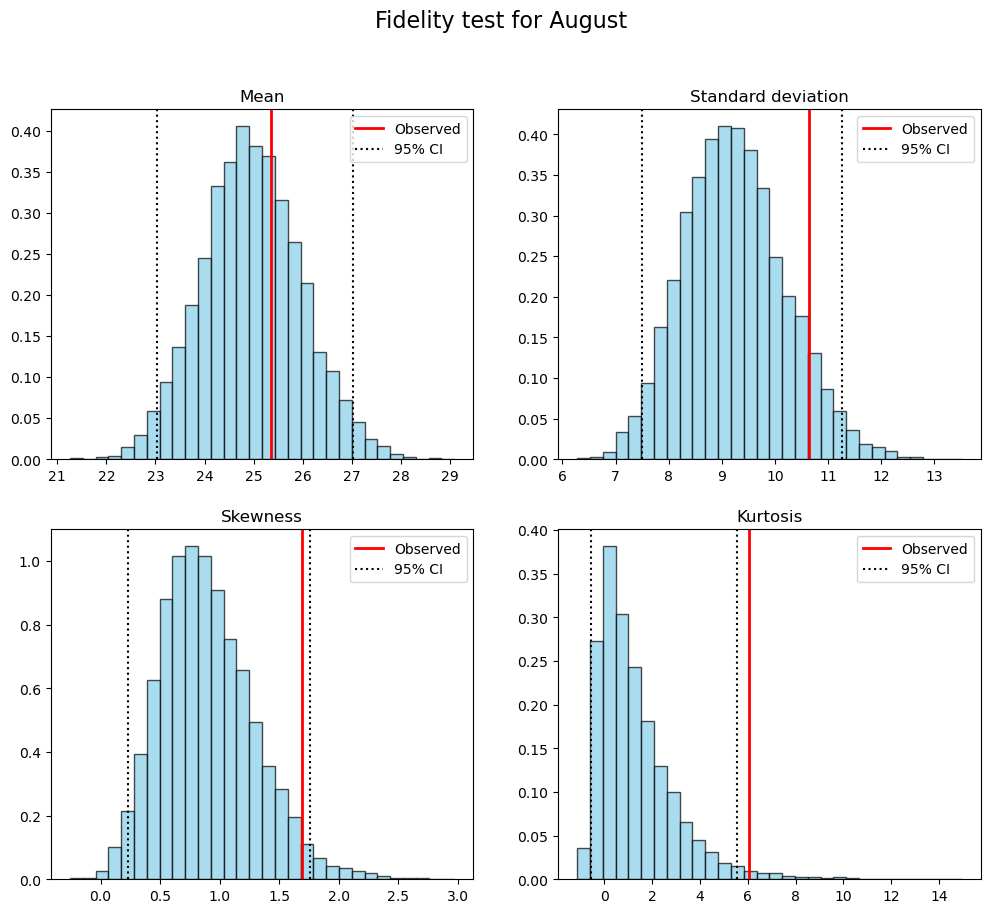

In [16]:
fid.plot(rea, mod, "figures/august", "August", show=True)

In [17]:
corrected_3 = corrected_1 ** 1.1
maxs_corrected_3 = corrected_3.max(dim="time")
corrected_3.to_netcdf("august/corrected_3.nc")
maxs_corrected_3.to_netcdf("august/maxs_corrected_3.nc")

In [ ]:
rea, mod = fid.main(
    "august/corrected_3.nc",
    "data/processed-rea-2.nc"
)
fid.plot(rea, mod, "figures/august", "August", show=True)